In [2]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import xgboost as xgb

D:\Users\anast\PycharmProjects\ProphetForecast\.venv\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
import pandas as pd

df = pd.read_csv("feature_engineered.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.dropna()

In [4]:
train = df.loc["2013-01-01":"2013-12-31"]
test = df.loc["2014-01-01":"2014-03-31"]

X_train = train.drop(columns=["unit_sales"])
y_train = train["unit_sales"]

X_test = test.drop(columns=["unit_sales"])
y_test = test["unit_sales"]

In [5]:
space = {
    "n_estimators": hp.choice("n_estimators", [50, 100, 200, 300]),
    "max_depth": hp.choice("max_depth", [2, 3, 4, 5, 6]),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.3),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0)
}

In [6]:
def objective(params):
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        **params
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    return {
        "loss": rmse,
        "status": STATUS_OK
    }

In [7]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(42)
)

best

100%|██████████| 30/30 [00:04<00:00,  7.06trial/s, best loss: 136.3097782715581]


{'colsample_bytree': np.float64(0.9819121786756363),
 'learning_rate': np.float64(0.08781417857605588),
 'max_depth': np.int64(0),
 'n_estimators': np.int64(2),
 'subsample': np.float64(0.6138813743427279)}

In [8]:
best_xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=[50, 100, 200, 300][best["n_estimators"]],
    max_depth=[2, 3, 4, 5, 6][best["max_depth"]],
    learning_rate=best["learning_rate"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"]
)

best_xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.9819121786756363)
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [9]:
# Evaluate tuned XGBoost model

best_xgb_pred = best_xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, best_xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, best_xgb_pred))
r2 = r2_score(y_test, best_xgb_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 89.77
RMSE: 136.31
R²: 0.4872


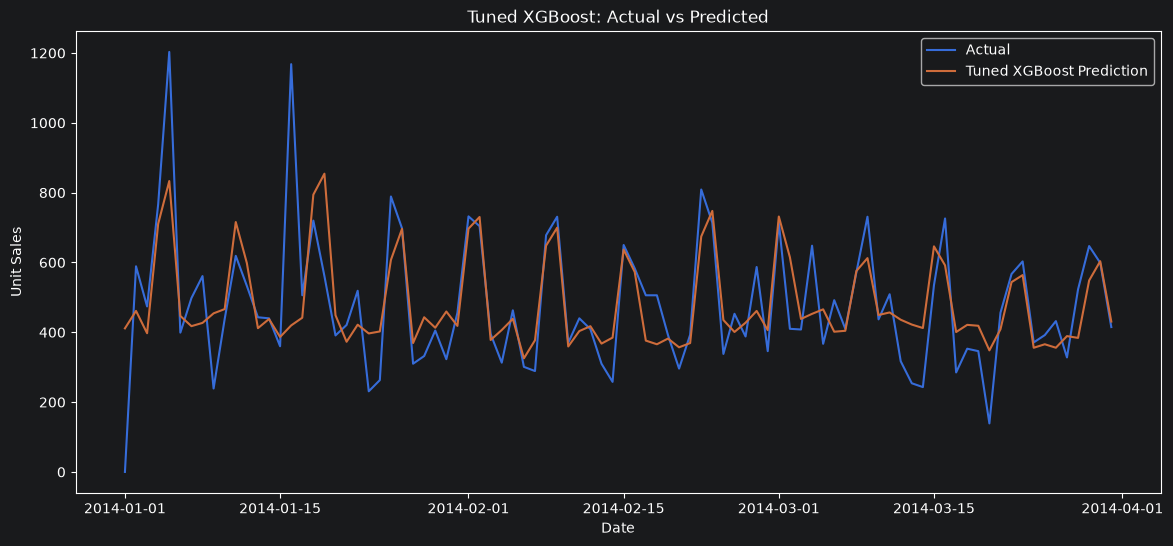

In [10]:
# Plot actual vs predicted

plt.figure(figsize=(14, 6))

plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, best_xgb_pred, label="Tuned XGBoost Prediction")

plt.title("Tuned XGBoost: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

In [11]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "Tuned XGBoost"],
    "MAE": [91.40, mae],
    "RMSE": [143.47, rmse],
    "R²": [0.4319, r2]
})

comparison

,Model,MAE,RMSE,R²
0,XGBoost,91.400000,143.470000,0.431900
1,Tuned XGBoost,89.767744,136.309778,0.487167


Hyperparameter tuning improved the XGBoost model performance. The tuned model achieved a lower MAE and RMSE and a higher R² score compared to the baseline XGBoost model. This indicates that tuning helped the model better capture the sales patterns and reduced prediction errors.

## LSTM (Long Short-Term Memory)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras_tuner as kt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
df = pd.read_csv("feature_engineered.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.dropna()

series = df[["unit_sales"]].values

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

In [19]:
# Create sequences
def create_sequences(data, window_size):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [20]:
window_size = 30

X, y = create_sequences(series_scaled, window_size)

split_date = pd.Timestamp("2014-01-01")
split_idx = df.index.get_loc(split_date) - window_size

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [21]:
# LSTM model for tuning
def build_lstm_model(hp):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.LSTM(
        units=hp.Int("units", min_value=32, max_value=128, step=32),
        activation="tanh",
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))

    model.add(tf.keras.layers.Dropout(
        rate=hp.Float("dropout", min_value=0.0, max_value=0.4, step=0.1)
    ))

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice("learning_rate", [0.001, 0.0005, 0.0001])
        ),
        loss="mse"
    )

    return model

In [23]:
# Start tuner
tuner = kt.RandomSearch(
    build_lstm_model,
    objective="val_loss",
    max_trials=10,
    executions_per_trial=1,
    directory="lstm_tuning",
    project_name="sales_forecast"
)

tuner.search(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


Trial 10 Complete [00h 00m 10s]
val_loss: 0.020932108163833618

Best val_loss So Far: 0.020610488951206207
Total elapsed time: 00h 03m 24s


In [24]:
#  Train best model
best_lstm_model = tuner.get_best_models(num_models=1)[0]

history = best_lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

D:\Users\anast\PycharmProjects\ProphetForecast\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


D:\Users\anast\PycharmProjects\ProphetForecast\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0209 - val_loss: 0.0206
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0205 - val_loss: 0.0206
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0200 - val_loss: 0.0206
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0193 - val_loss: 0.0205
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0187 - val_loss: 0.0203
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0183 - val_loss: 0.0203
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0193 - val_loss: 0.0203
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0189 - val_loss: 0.0203
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0192 - val_loss: 0.0201
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0187 - val_loss: 0.0201
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0197 - val_loss: 0.0200
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0191 - val_loss: 0.0201
Epoch 13/50


In [25]:
# evaluation
lstm_pred_scaled = best_lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_real = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_real, lstm_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, lstm_pred))
r2 = r2_score(y_test_real, lstm_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
MAE: 141.30
RMSE: 188.45
R²: 0.0198


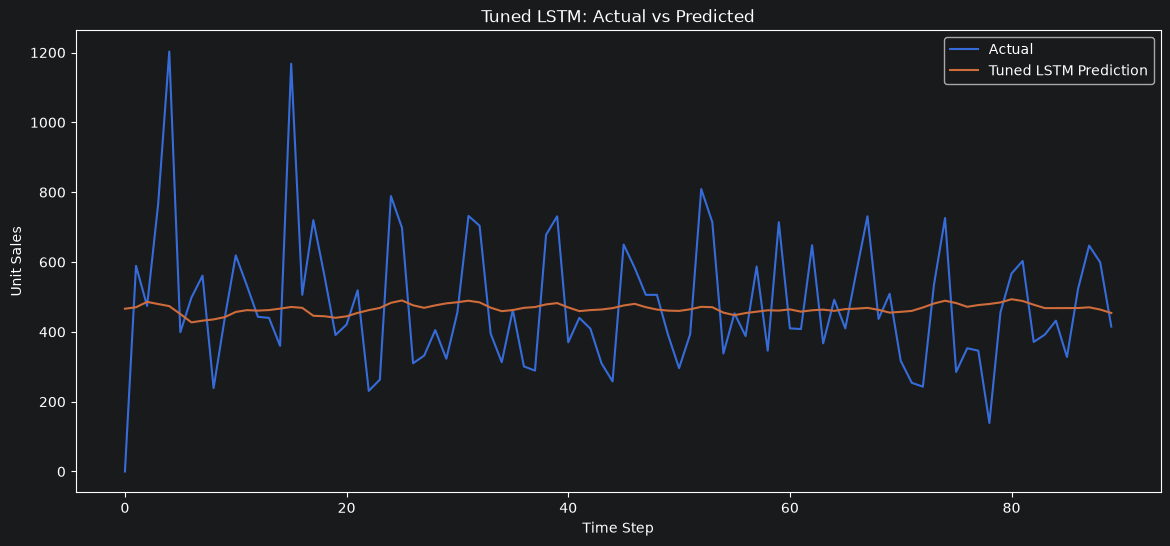

In [26]:
plt.figure(figsize=(14,6))

plt.plot(y_test_real, label="Actual")
plt.plot(lstm_pred, label="Tuned LSTM Prediction")

plt.title("Tuned LSTM: Actual vs Predicted")
plt.xlabel("Time Step")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

The tuned LSTM model did not perform well on this dataset. The predictions remained almost constant and failed to capture the sharp peaks and fluctuations in unit sales, indicating underfitting. This is likely due to the relatively small training dataset (approximately one year of daily observations), which is insufficient for effectively training a deep learning model such as LSTM.

In [12]:
import joblib

joblib.dump(best_xgb_model, "tuned_xgboost.pkl")

print("Champion model saved successfully!")

Champion model saved successfully!


## Conclusion:

Overall, the tuned LSTM achieved the weakest performance among the evaluated models. Simpler machine learning models, particularly Linear Regression and the tuned XGBoost model, produced more accurate forecasts for this dataset.